In [1]:
import os 
os.environ['JAX_PLATFORMS'] = 'cpu'

import scb_multiome as scbm 
import scanpy as sc 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns 


In [2]:
BASE_DIR = "/mnt/fxcai/nfs_share2"
data_dir = "../../data"
atac_path = f"{data_dir}/atac_data/ad_atac_132k.h5ad"
rna_path = f"{data_dir}/rna_data/tfs.h5ad"
preprocess_folder_acc = f"{data_dir}/atac_data/scb_processed"
preprocess_folder_rna = f"{data_dir}/rna_data"
chippath = f"{data_dir}/chip_data/atac_132k_encode_byTF.csv"
gt_path = f"{data_dir}/chip_data/blood_gt.csv"
fimo_dir = f"{data_dir}/all_seq_match/fimo_res.csv"
spearmanr_dir = f"{data_dir}/spearmanR/SpearmanR.csv"

result_dir = "."

## shortcut to collapse cell dimension for gradTF & gradSeq
The above benchmark is only on a subset of peaks because the full gradSeq & gradTF are too large (n_peak=131511, n_cell=9543, n_tf=322). 

To benchmark on all peaks, we take mean TF expression (ie, n_cell=1) for speedup, but the value will be different. 

In [3]:
import json 
import pickle5 
import h5py 

In [4]:
ad_atac = sc.read_h5ad(atac_path)
ad_rna = sc.read_h5ad(rna_path)
sc.pp.scale(ad_rna)

chip_bulk = pd.read_csv(chippath, index_col=0)
df_gt = pd.read_csv(gt_path, index_col=0)
act_pval = pd.read_csv(fimo_dir, index_col=0)
celltype_specific_SpearmanR = pd.read_csv(spearmanr_dir, index_col=0)

tfs_cts = df_gt.columns
jaspar_motifs = scbm.pp.read_JASPAR_pwms(f"{BASE_DIR}/genomes/JASPAR_human_TFs_meme/20230424043428_JASPAR2022_combined_matrices_2028_meme.txt")
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin(ad_rna.var['gene_symbols'])]
jaspar_motifs = jaspar_motifs[jaspar_motifs['tf'].isin([tf_ct.split("_")[0] for tf_ct in tfs_cts])]
### reindex for writing grads below  
jaspar_motifs = jaspar_motifs.reset_index(drop=True)

peak_emb = pd.read_csv("./benchmark_summarize/peak_emb.csv", index_col=0)

In [7]:
acc_pred_no_dpth = np.load("./benchmark_summarize/acc_pred_no_dpth.npz")['arr_0']
acc_pred_no_dpth_df = pd.DataFrame(acc_pred_no_dpth, index=ad_atac.var.index, columns=ad_atac.obs.index)
acc_pred_no_dpth_df = acc_pred_no_dpth_df.T
acc_pred_no_dpth_df['celltype'] = ad_rna.obs['celltype']
acc_pred_no_dpth_df = acc_pred_no_dpth_df.groupby("celltype").mean().T
acc_pred_no_dpth_df[:5]

celltype,CD56 (bright) NK cells,CD56 (dim) NK cells,MAIT T cells,classical monocytes,effector CD8 T cells,intermediate monocytes,memory B cells,memory CD4 T cells,myeloid DC,naive B cells,naive CD4 T cells,naive CD8 T cells,non-classical monocytes,plasmacytoid DC
chr1:9790-10675,0.011576,0.011343,0.009849,0.007213,0.009581,0.007184,0.005742,0.009219,0.007032,0.005424,0.007202,0.007039,0.006995,0.006722
chr1:180599-181702,0.029746,0.025916,0.020667,0.013128,0.020815,0.013144,0.011641,0.017710,0.013837,0.010869,0.015242,0.015508,0.012826,0.017574
chr1:191168-192093,0.007098,0.006801,0.006122,0.008001,0.006612,0.007954,0.003181,0.006461,0.007998,0.003157,0.006727,0.006984,0.007793,0.009641
chr1:267565-268455,0.016789,0.016134,0.015714,0.041190,0.015520,0.041266,0.018739,0.015934,0.038289,0.017471,0.014828,0.014559,0.040551,0.030426
chr1:270876-271770,0.001047,0.000988,0.000832,0.016340,0.000953,0.015998,0.001707,0.001018,0.013036,0.001333,0.000982,0.000950,0.014454,0.004711


In [8]:
## filter out TFs without available encode data 
tfs_gt = df_gt.columns.str.split("_").str[0]
df_gt = df_gt.loc[:,tfs_gt.isin(chip_bulk.columns)]
print(df_gt.shape)

(131511, 11)


#### gradTF & gradSeq for all peaks 

In [ ]:
with open(f"{result_dir}/config.json") as f:
    config_d = json.load(f)
    
model = scbm.core.scb_TFs.Model(preprocess_folder_acc = preprocess_folder_acc,
                                preprocess_folder_rna=preprocess_folder_rna,
                                atac = ad_atac.X.T,
                                rna = ad_rna.X,
                                model_config=config_d['model_config']
                                )
model.create_model()
all_ds = model.read_accrna_ds(ds_key='all')

with open(f"{result_dir}/result.pkl", "rb") as handle:
    data = pickle5.load(handle)
model.load_data(data,
                keys = ['params_all',])

In [6]:
cts = df_gt.columns.str.split("_").str[1].unique()

with h5py.File("./benchmark_summarize/grad_allpeak_bycelltype.h5", 'w') as hf:
    grad_tf_gp = hf.create_group('grad_tf',) 
    grad_seq_gp = hf.create_group('grad_seq',) 
    for ct in cts:
        print(ct)
        
        ## subset to cells matching ct        
        cells_select = ad_rna.obs['celltype'] == ct
        ds_in = all_ds.copy()
        ds_in['rna'] = np.mean(all_ds['rna'][cells_select,:], axis=0, keepdims=True)  #(1,n_tf)
        ds_in['atac_dpth'] = np.mean(all_ds['atac_dpth'], keepdims=True) # keep mean
        
        gradtf = scbm.utils.get_grad_tf_small(model=model,
                                            all_ds=ds_in)
        gradtf = np.squeeze(gradtf)
        grad_tf_gp.create_dataset(ct, data=gradtf)
        gradseq = scbm.utils.get_grad_seq_small(model=model, 
                                            all_ds = ds_in,
                                            jaspar_motifs=jaspar_motifs
                                            )
        gradseq = np.squeeze(gradseq)
        grad_seq_gp.create_dataset(ct, data=gradseq)

classical monocytes


100%|██████████| 131511/131511 [01:44<00:00, 1257.41it/s]


max_len=35


100%|██████████| 131511/131511 [03:27<00:00, 632.72it/s]


naive B cells


...

100%|██████████| 131511/131511 [03:23<00:00, 645.41it/s]


myeloid DC


100%|██████████| 131511/131511 [01:41<00:00, 1292.10it/s]


max_len=35


100%|██████████| 131511/131511 [03:27<00:00, 633.70it/s]


#### extract the TFs & motifs in groundtruth & convert to df

In [6]:
gradSeq = pd.DataFrame(index=ad_atac.var_names)
gradTF = pd.DataFrame(index=ad_atac.var_names)
with h5py.File("./benchmark_summarize/grad_allpeak_bycelltype.h5", 'r') as hf:
    for tf_ct in df_gt.columns:
        tf, ct = tf_ct.split("_")[0], tf_ct.split("_")[1]
        tf_idx = np.where(ad_rna.var['gene_symbols'] == tf)[0][0]
        motifs = jaspar_motifs[jaspar_motifs['tf'] == tf]['motif']
        gradSeq[[f"{tf}:{mm}_{ct}" for mm in motifs]] = hf['grad_seq'][ct][:,motifs.index.to_numpy()]
        gradTF[f"{tf}_{ct}"] = hf['grad_tf'][ct][:, tf_idx]

gradSeq[:5]  

,CTCF:MA1930.1_classical monocytes,CTCF:MA0139.1_classical monocytes,CTCF:MA1929.1_classical monocytes,CTCF:MA1930.1_naive B cells,CTCF:MA0139.1_naive B cells,CTCF:MA1929.1_naive B cells,ETS1:MA0098.3_naive CD4 T cells,IRF1:MA0050.2_classical monocytes,IRF4:MA1419.1_naive B cells,MYC:MA0059.1_naive B cells,MYC:MA0147.3_naive B cells,REST:MA0138.2_naive CD4 T cells,RUNX1:MA0002.1_classical monocytes,RUNX1:MA0002.1_myeloid DC,RUNX1:MA0002.1_naive CD4 T cells,STAT1:MA0517.1_classical monocytes,STAT1:MA0137.3_classical monocytes
chr1:9790-10675,0.001711,0.002115,0.001661,0.002241,0.002691,0.002056,0.008606,0.002150,0.003410,0.003002,0.003468,0.003008,0.002167,0.002041,0.005245,0.002464,0.002268
chr1:180599-181702,0.004528,0.004601,0.004261,0.003866,0.003685,0.003805,0.007011,0.005119,0.005234,0.004902,0.005356,0.007008,0.004772,0.004826,0.006569,0.005177,0.003792
chr1:191168-192093,0.006123,0.006851,0.005791,0.001270,0.001683,0.001312,0.002964,0.006397,0.001829,0.001621,0.001761,0.003395,0.007710,0.007694,0.002363,0.007126,0.006989
chr1:267565-268455,0.010384,0.013817,0.010742,0.003584,0.004097,0.003815,0.005638,0.009491,0.004581,0.005554,0.005520,0.004684,0.012070,0.009544,0.004948,0.009972,0.009132
chr1:270876-271770,0.006207,0.006134,0.005978,0.000848,0.000813,0.000809,0.000780,0.008560,0.001009,0.000737,0.000798,0.000640,0.008400,0.006458,0.000787,0.008881,0.010727


### benchmark as above

In [10]:
def build_prod_scaled_model(metrics=[], trainOn='gt', gt_downsample=0.01):
        if trainOn == "gt":
                bm_noisy_prod = scbm.utils.tf_act_cross_peaks_prod_acc(gt=df_gt, 
                                metrics=metrics,
                                jaspar_motifs=jaspar_motifs,
                                chip_bulk=None,
                                pred_acc=acc_pred_no_dpth_df
                                )
                bm_noisy_prod.logReg_all(downsample_frac=gt_downsample, trainOn="gt")

                bm_noisy_prod_scale = scbm.utils.tf_act_cross_peaks_alt(gt=df_gt, 
                                                                metrics=[ bm_noisy_prod.y_pred
                                                                        ],
                                                                jaspar_motifs=jaspar_motifs,
                                                                chip_bulk=chip_bulk,
                                                                # pred_acc=acc_pred_no_dpth_df
                                                                )
                bm_noisy_prod_scale.logReg_all(downsample_frac=1., trainOn="gt")
                return bm_noisy_prod_scale
        elif trainOn == "chip_bulk":
                bm_noisy_prod = scbm.utils.tf_act_cross_peaks_prod_acc(gt=df_gt, 
                                metrics=metrics,
                                jaspar_motifs=jaspar_motifs,
                                chip_bulk=chip_bulk,
                                pred_acc=acc_pred_no_dpth_df
                                )
                bm_noisy_prod.logReg_all(downsample_frac=1., trainOn="chip_bulk")
                bm_noisy_prod_scale = scbm.utils.tf_act_cross_peaks_alt(gt=df_gt, 
                                                        metrics=[ bm_noisy_prod.y_pred
                                                                ],
                                                        jaspar_motifs=jaspar_motifs,
                                                        chip_bulk=chip_bulk,
                                                        # pred_acc=acc_pred_no_dpth_df
                                                        )
                bm_noisy_prod_scale.logReg_all(downsample_frac=1., trainOn="gt")
                return bm_noisy_prod_scale
        else:
                raise Exception("trainOn is gt or chip_bulk")

In [13]:
### same as clustering 
from tqdm import tqdm 
gradSeq_ids = pd.DataFrame({"tf": gradSeq.columns.str.split(":").str[0],
                            "mm": gradSeq.columns.str.split(":").str[1].str.split("_").str[0],
                            "ct": gradSeq.columns.str.split(":").str[1].str.split("_").str[1:].str.join("_"),
                            "tf:mm" : gradSeq.columns.str.split("_").str[0]
                            }, index=gradSeq.columns)

acc_pred_no_dpth_expand = pd.DataFrame(
            {f"{tf}:{mm}_{ct}" : acc_pred_no_dpth_df.loc[gradSeq.index, ct]     #(peak, cell), same across tfs
            for tf, mm, ct in tqdm(zip(gradSeq_ids['tf'], gradSeq_ids['mm'], gradSeq_ids['ct']))}
            )

acc_pred_no_dpth_expand_norm = acc_pred_no_dpth_expand.div(acc_pred_no_dpth_expand.sum(axis=1), axis=0)

gradTF_expand = pd.DataFrame(
            {f"{tf}:{mm}_{ct}" : gradTF[f"{tf}_{ct}"] 
            for tf, mm, ct in tqdm(zip(gradSeq_ids['tf'], gradSeq_ids['mm'], gradSeq_ids['ct']))}
            )

gradTF_weighted_expand = acc_pred_no_dpth_expand_norm * gradTF_expand/(acc_pred_no_dpth_expand_norm.sum(axis=0))  

tf_act_weighted = gradTF_weighted_expand*gradSeq

scale_factor = 1e10
bm_grads_prod_scale = scbm.utils.tf_act_cross_peaks_alt(gt=df_gt, 
                                                metrics=[ tf_act_weighted*scale_factor
                                                        ],
                                                jaspar_motifs=jaspar_motifs,
                                                chip_bulk=chip_bulk,
                                                # pred_acc=acc_pred_no_dpth_df
                                                )
bm_grads_prod_scale.logReg_all(downsample_frac=1., trainOn="gt")

0it [00:00, ?it/s]

17it [00:00, 119.79it/s]
17it [00:00, 108363.48it/s]
100%|██████████| 11/11 [00:01<00:00,  6.13it/s]


In [12]:
scale_factor = 1
bm_baseline_prod_scaled = build_prod_scaled_model(metrics=[act_pval, celltype_specific_SpearmanR], trainOn='gt')
bm_std_prod_scaled = build_prod_scaled_model(metrics=[act_pval, celltype_specific_SpearmanR, gradSeq*scale_factor, gradTF*scale_factor], trainOn='gt')
bm_extended_prod_scaled = build_prod_scaled_model(metrics=[act_pval, celltype_specific_SpearmanR, peak_emb, gradTF*scale_factor], trainOn='gt')

bm_baseline_noisy_prod_scaled = build_prod_scaled_model(metrics=[act_pval, celltype_specific_SpearmanR], trainOn='chip_bulk')
bm_std_noisy_prod_scaled = build_prod_scaled_model(metrics=[act_pval, celltype_specific_SpearmanR, gradSeq*scale_factor, gradTF*scale_factor], trainOn='chip_bulk')

bm_grads_noisy_prod_scaled = build_prod_scaled_model(metrics=[gradSeq*scale_factor, gradTF*scale_factor], trainOn='chip_bulk')
bm_extended_noisy_prod_scaled = build_prod_scaled_model(metrics=[act_pval, celltype_specific_SpearmanR, peak_emb, gradTF*scale_factor], trainOn='chip_bulk')

100%|██████████| 11/11 [00:02<00:00,  5.12it/s]


In [14]:
bm_to_plot_dict = {
    "baseline on groundtruth ChIP": bm_baseline_prod_scaled, 
    "standard on groundtruth ChIP": bm_std_prod_scaled,
    "extended on groundtruth ChIP": bm_extended_prod_scaled,
    
    
    "baseline on pan-cell ChIP": bm_baseline_noisy_prod_scaled,
    "standard on pan-cell ChIP": bm_std_noisy_prod_scaled,
    "extended on pan-cell ChIP": bm_extended_noisy_prod_scaled,
    
    "normalized gradients product": bm_grads_prod_scale,
    
    # "linger": bm_linger
                    }


In [15]:
y_pred_auprc = scbm.utils.get_auprc_cross_tfs(bm_to_plot_dict, df_gt=df_gt)
auprc_cross_peak = scbm.utils.get_auprc_cross_peaks(bm_to_plot_dict, df_gt=df_gt)

100%|██████████| 11/11 [00:00<00:00, 42.30it/s]


In [16]:
res_old = auprc_cross_peak
res_old['tf_ct'] = auprc_cross_peak.index
res_plot = res_old.melt(
    value_vars=[c for c in res_old.columns if c != "tf_ct"], 
    id_vars=['tf_ct'])

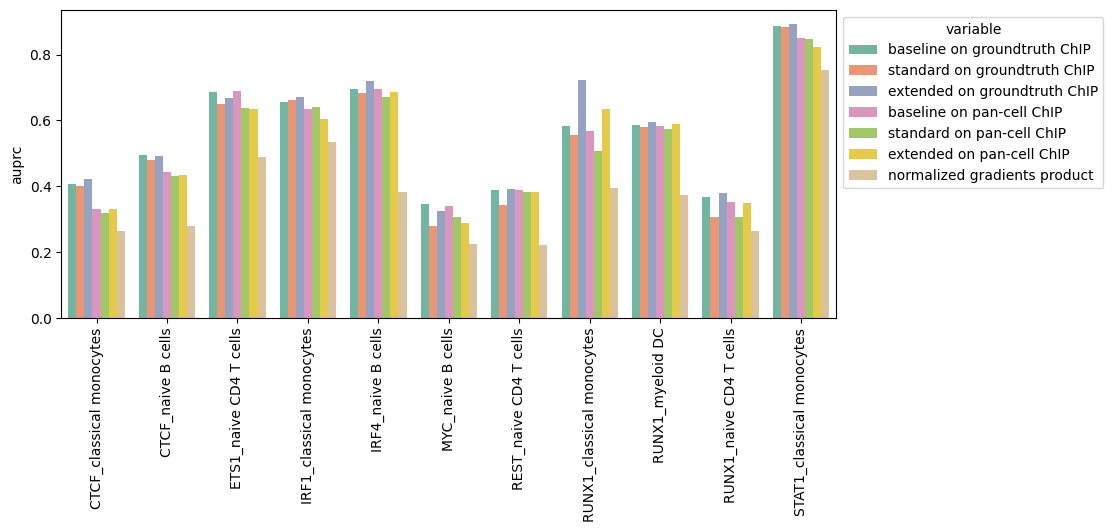

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=res_plot, x = "tf_ct", y="value", 
            hue='variable', 
            palette="Set2", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("auprc")
ax.tick_params(axis='x', rotation=90)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

Text(0, 0.5, 'auprc')

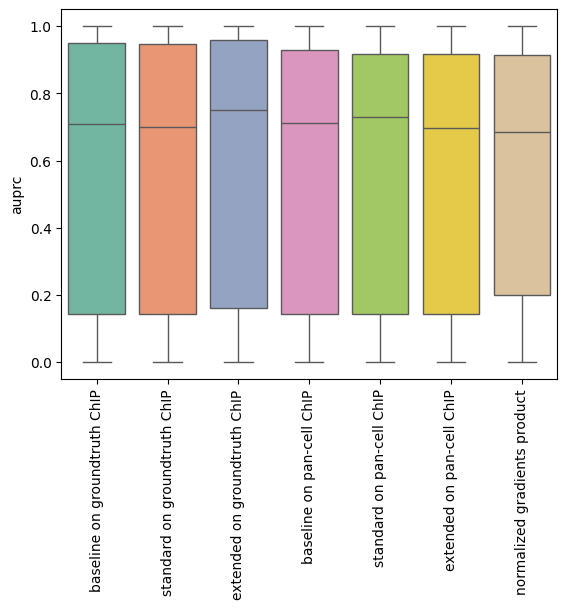

In [18]:
fig, ax=plt.subplots()
sns.boxplot(y_pred_auprc, ax=ax, palette="Set2")
ax.tick_params(axis='x', rotation=90)
ax.set_ylabel("auprc")

In [ ]:
# fig.savefig("./figs/auprcs_allpeaks.svg", dpi=300, bbox_inches='tight')